# 🎵 Spotify EDA — Exploratory Data Analysis
### Exploring what makes a song popular

In this notebook we explore a Spotify dataset with 114k+ tracks
to find patterns in audio features and understand what drives popularity.

In [25]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [26]:
# Load dataset
df = pd.read_csv('../data/raw/dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset shape: (114000, 21)
Rows: 114,000
Columns: 21


In [27]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [28]:
df = df.drop('Unnamed: 0', axis = 1) # Drop unnamed index column
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [29]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [30]:
# Drop null values
df = df.dropna()
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [31]:
df.dtypes

track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

In [32]:
# Convert duration from milliseconds to seconds
df['duration_s'] = df['duration_ms'] / 1000
df = df.drop('duration_ms', axis = 1) # 
df

,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,230.666
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,149.610
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,210.826
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,201.933
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,198.853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,384.999
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,385.000
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,271.466
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,283.893


In [33]:
# Check for duplicates
print(f"Duplicates: {df.duplicated().sum()}")

# Basic stats
df.describe()

Duplicates: 450


,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_s
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034,228.031153
std,22.304959,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623,107.296058
min,0.000000,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.586000
25%,17.000000,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000,174.066000
50%,35.000000,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,212.906000
75%,50.000000,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000,261.506000
max,100.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,5237.295000


In [34]:
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

Shape after dropping duplicates: (113549, 20)


In [35]:
df.sort_values('duration_s', ascending=False).head(20)

,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s
73617,3Cnz3Bu9Wcw8p3kiBTXTxp,Tale Of Us,Unity (Voyage Mix),Unity (Voyage Mix) Pt. 1,35,False,0.6950,0.736000,5,-11.371,0,0.0374,0.003990,0.860000,0.0910,0.05090,124.001,4,minimal-techno,5237.295
10935,0LBIf9EFHuxmuNig4JHGZo,Timo Maas,Crossing Wires 002 - Compiled And Mixed By Tim...,Crossing Wires 002 - Continuous DJ Mix,11,False,0.6970,0.632000,1,-12.469,1,0.0451,0.008150,0.871000,0.0998,0.15100,121.055,4,breakbeat,4789.026
24348,6wypxnAvmv5zYewUX3VFDd,Seth Troxler,Seth Troxler - The Lab 03,The Lab 03 - Continuous DJ Mix Part 1,8,False,0.6840,0.656000,5,-11.163,0,0.0633,0.019100,0.848000,0.1030,0.30100,123.180,4,detroit-techno,4730.302
73840,6JbQr97EMFD2D3Ek6gxgt1,Loco Dice,Amnesia Ibiza - Underground 10,Amnesia Ibiza Underground 10 DJ Mix,17,False,0.7830,0.728000,10,-10.176,0,0.0612,0.001580,0.840000,0.1580,0.18900,125.044,4,minimal-techno,4563.897
13344,3gFme8BdfTtFHxKmuTnSbj,Mark Farina,House of OM (DJ Mix),House of Om - Mark Farina - Continuous Mix,11,False,0.8610,0.805000,11,-6.461,0,0.0711,0.005480,0.577000,0.1350,0.54500,129.306,4,chicago-house,4447.520
13245,13hQAhg1owjTpTcI9xQc6c,Mark Farina,Live In Tokyo,Live In Tokyo - Continuous Mix,11,False,0.8060,0.582000,1,-12.181,1,0.0874,0.008300,0.237000,0.3280,0.68600,128.368,4,chicago-house,4339.826
13195,3se0UYprtkHthJEBuk1A5K,Mark Farina,Greenhouse Construction,Greenhouse Construction,12,False,0.8460,0.744000,10,-9.260,0,0.0611,0.003710,0.335000,0.3130,0.53200,125.434,4,chicago-house,4334.721
27926,6eTDnsdPlRUyrTHqFj3l7W,Lenzman;Dan Stezo,NQ State of Mind,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",15,True,0.5930,0.924000,1,-3.979,1,0.0899,0.003690,0.022100,0.5340,0.24200,173.938,4,drum-and-bass,4246.206
101390,2QfFLpSGF1T1pY6tq4kD7Z,Ocean Sounds,Ocean Waves Sounds to Relax and Sleep,Ocean Waves Sounds,39,False,0.0797,0.995000,1,-17.379,1,0.0612,0.932000,0.562000,0.3100,0.00001,84.788,3,sleep,4120.258
45063,0PINNy1r5eEILOuHpnjl5d,Estas Tonne,Internal Flight (Remastered),Internal Flight (Remastered),47,False,0.3000,0.640000,4,-9.266,0,0.0367,0.946000,0.893000,0.0783,0.21200,159.624,4,guitar,3876.276


In [36]:
# Filter out tracks longer than 10 minutes (likely podcasts or audiobooks)
df = df[df['duration_s'] < 600]
print(f"Shape after filtering duration: {df.shape}")

Shape after filtering duration: (112951, 20)


## Data Cleaning Summary

- Dropped unnamed index column
- Removed 3 rows with null values
- Converted duration from milliseconds to seconds
- Removed 450 duplicate rows
- Filtered out 1,048 tracks longer than 10 minutes (podcasts/audiobooks)

**Final dataset: 112,951 tracks | 20 columns**

## Exploratory Data Analysis


<Axes: xlabel='popularity', ylabel='Count'>

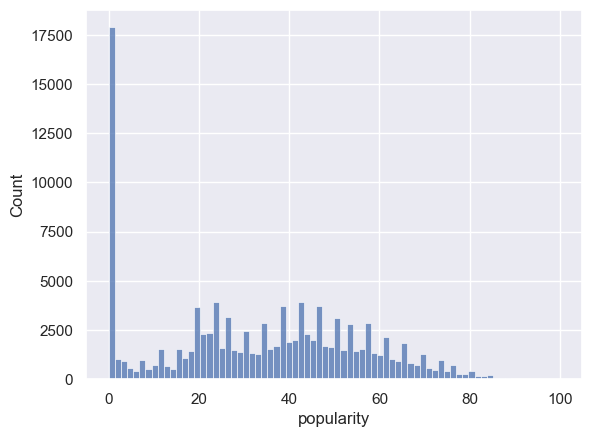

In [37]:
sns.histplot(df['popularity']) 

In [38]:
# Filter out tracks with popularity levels lower than 5
df = df[df['popularity'] > 5 ]
print(f"Shape after filtering popularity: {df.shape}")

Shape after filtering popularity: (92524, 20)


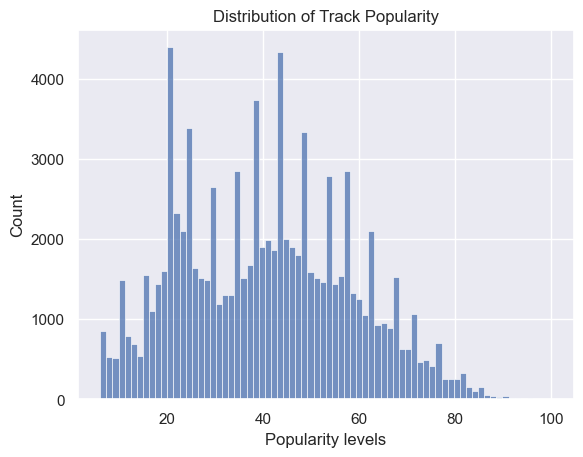

In [39]:
# Plot popularity distribution
sns.histplot(df['popularity'])
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity levels')

# Save figure
plt.savefig('../images/popularity_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

In [40]:
# Top 10 most popular genres
top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
print(top_genres)


track_genre
dance          74.369128
rock           73.557312
pop            69.571429
electro        67.758491
house          67.308911
alternative    65.934247
hip-hop        64.587219
edm            64.509294
soul           63.692557
latin          62.258065
Name: popularity, dtype: float64


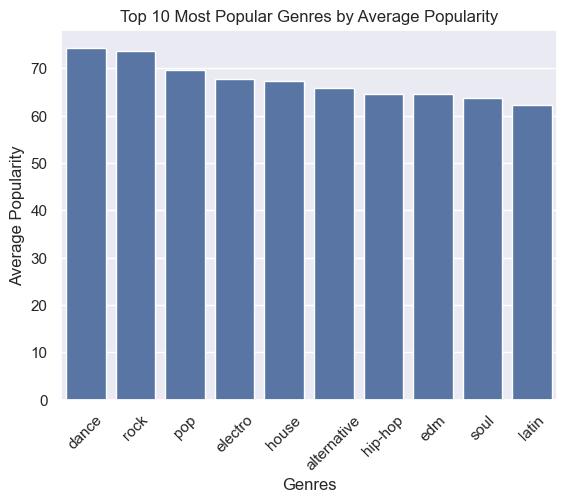

In [41]:
# Top 10 most popular genres visualization
sns.barplot(x=top_genres.index, y=top_genres.values)
plt.title('Top 10 Most Popular Genres by Average Popularity')
plt.xlabel('Genres')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45)

# Save figure
plt.savefig('../images/top_genres.png', dpi=150, bbox_inches='tight')

plt.show()

In [42]:
# Top 10 most popular artists by average popularity
top_artists = df.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)
print(top_artists)

artists
Sam Smith;Kim Petras          100.0
Bizarrap;Quevedo               99.0
Manuel Turizo                  98.0
Bad Bunny;Chencho Corleone     97.0
Bad Bunny;Bomba Estéreo        94.5
Joji                           94.0
Beyoncé                        93.0
Rema;Selena Gomez              92.0
Harry Styles                   92.0
Drake;21 Savage                91.0
Name: popularity, dtype: float64


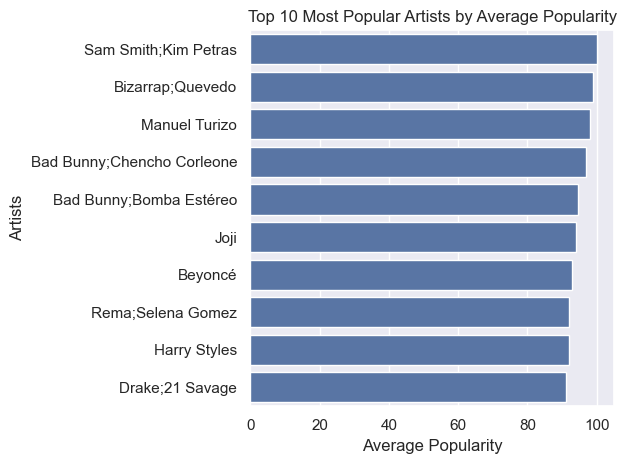

In [43]:
# Top 10 most popular artists visualization
sns.barplot(x=top_artists.values, y=top_artists.index, orient='h')
plt.title('Top 10 Most Popular Artists by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artists')
plt.tight_layout()
plt.savefig('../images/top_artists.png', dpi=150, bbox_inches='tight')
plt.show()

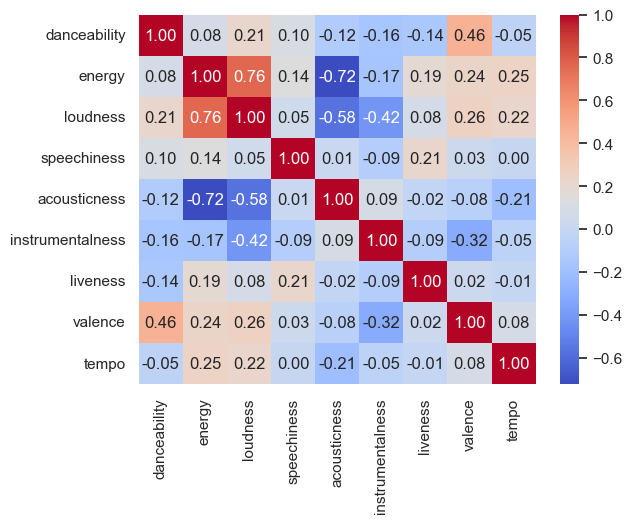

In [44]:
# Correlation heatmap of audio features
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

corr_matrix = df[features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')

### Key Correlations Found
- **Energy & Loudness (0.76):** Louder songs tend to be more energetic
- **Energy & Acousticness (-0.72):** The strongest negative correlation, acoustic songs are rarely high energy
- **Danceability & Valence (0.46):** More danceable songs tend to sound happier
- **Instrumentalness & Loudness (-0.42):** Instrumental tracks tend to be quieter

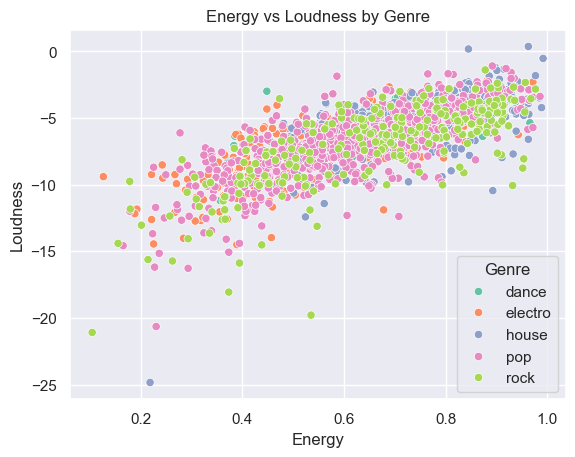

In [45]:
# Filter top 5 genres
top5_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(5).index
df_top5 = df[df['track_genre'].isin(top5_genres)]

# Scatter plot with the key correlation between energy and loudness, colored by genre
sns.scatterplot(x='energy', y='loudness', data=df_top5, hue='track_genre', palette='Set2')
plt.title('Energy vs Loudness by Genre')
plt.xlabel('Energy')
plt.ylabel('Loudness')
plt.legend(title='Genre')
plt.savefig('../images/energy_loudness_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Insights — Energy vs Loudness by Genre

- **Dance and rock cluster in the upper right corner, indicating both high energy and high loudness.**
- **Pop shows wider dispersion, covering a broader range of energy and loudness levels.**
- **Acoustic genres are absent from this top 5, consistent with the -0.72 correlation between energy and acousticness.**
- **House maintains high energy levels regardless of loudness.**

## Popularity vs Audio Features

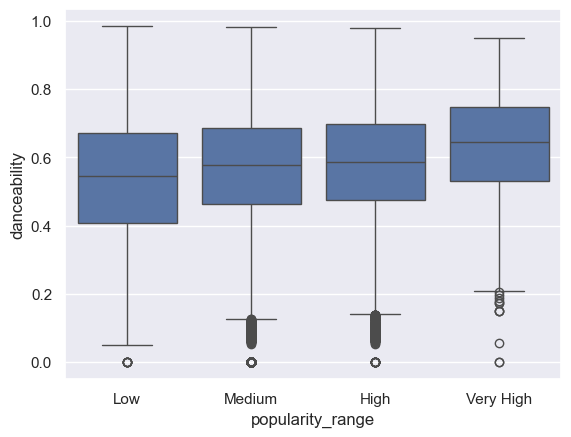

In [46]:
# Create popularity bins
df['popularity_range'] = pd.cut(df['popularity'], bins=[0, 25, 50, 75, 100], labels=['Low', 'Medium', 'High', 'Very High'])

sns.boxplot(x='popularity_range', y='danceability', data=df)
plt.savefig('../images/danceability_popularity_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Popularity vs Danceability
- **Danceability does not appear to be a strong predictor of popularity.** All popularity ranges show similar danceability distributions, suggesting that a song does not need to be highly danceable to be popular.

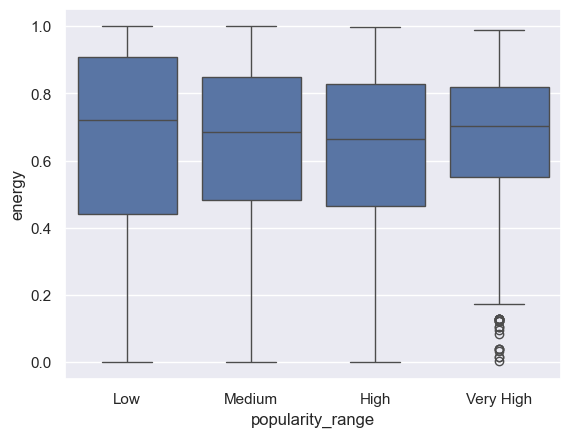

In [47]:
# Popularity vs Energy boxplot
sns.boxplot(x='popularity_range', y='energy', data=df)
plt.savefig('../images/energy_popularity_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

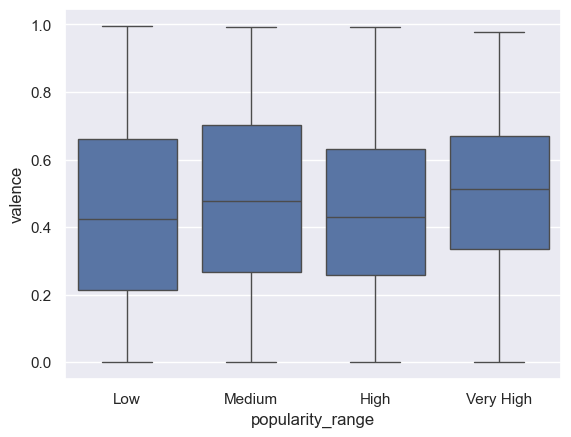

In [48]:
# Popularity vs Valence boxplot
sns.boxplot(x='popularity_range', y='valence', data=df)
plt.savefig('../images/valence_popularity_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Conclusions

- **Popularity is multifactorial:** No single audio feature strongly predicts whether a song will be popular.
- **Energy and Loudness** are the most correlated features (0.76), louder songs tend to be more energetic.
- **Acousticness and Energy** have the strongest negative correlation (-0.72), acoustic songs are rarely high energy.
- **Dance and Rock** dominate popularity rankings by genre, while artists like Sam Smith, Bizarrap and Bad Bunny lead individually.
- **Danceability, Energy and Valence** show similar distributions across all popularity ranges, confirming no single feature drives popularity alone.

In [50]:
# Save cleaned dataset
df.to_csv('../data/processed/dataset_clean.csv', index=False)
print("Clean dataset saved!")

Clean dataset saved!
